**Import modules**

In [1]:
import yaml
import jax.numpy as jnp
from ajx import Transform
from panda3d.core import loadPrcFileData
from ajx.example_environments.locked_dlo import LockedDLO
import matplotlib.pyplot as plt

loadPrcFileData("", "window-type offscreen")
loadPrcFileData("", "win-size 640 480")

import numpy as np 
from PIL import Image
from IPython.display import display

import jax

jax.config.update("jax_enable_x64", True)

from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.example_graphics.application import Application
#from ajx.constraints import ConstraintType
from ajx.example_environments.dlo import DLO, DLOSettings, CableParameters #LockedDLO
from ajx.simulation import SimulationSettings, Solver
import jax.numpy as jnp
import ajx.math as math
from ajx import Transform

#print(dir(DLO))




An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
#make sure correct ajx is running
import ajx
import ajx.simulation
import ajx.example_environments.environment

print(ajx.__file__)
print(ajx.simulation.__file__)
print(ajx.example_environments.environment.__file__)

/home/prinsesstrollet/DIGFYSIK/AJX/ajx/__init__.py
/home/prinsesstrollet/DIGFYSIK/AJX/ajx/simulation.py
/home/prinsesstrollet/DIGFYSIK/AJX/ajx/example_environments/environment.py


In the cell below data is read from a marker data file. A DLO environment i set up using LockedDLO, which disables movement in grippers(?). From the file a number of poses and some parameters are read. 

The following parameters are used:
- Inner radius: 0.013 m
- Outer radius: 0.0145 m
- Mass: 0.16 kg
- Length: 0.635 m
- n_segments: The real DLO uses 5 five marker sites (not including grippers) to estimate poses. This mean that we have six regions of DLO between the different markers. The number of bodies are set so that each of these regions have a certain resolution and we then add 5 extra segments for the positions of the markers. 

In [3]:
timestep = 1/60
grippermc_to_marker = jnp.array([0.0478024, 0, 0])

states = [] # Initialize list to store configurations

#Open marker data file
with open("marker_data_new/real_dlo_marker_data.yaml", "r") as stream:
    data_loaded = yaml.safe_load(stream)

#
gripper_com_to_marker = jnp.array(data_loaded["gripper_com_to_marker"])
env = LockedDLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=6*9+5,
        length=data_loaded["length"],
        inner_radius=data_loaded["inner_radius"],
        outer_radius = data_loaded["outer_radius"],
        density=data_loaded["mass"] / (data_loaded["length"]*jnp.pi*(data_loaded["outer_radius"]**2 - data_loaded["inner_radius"]**2)),
        pose_estimate_linear_offsets=data_loaded["marker_displacements"],
        gripper1_offset=Transform(gripper_com_to_marker, math.Rotations.identity),
        gripper2_offset=Transform(-gripper_com_to_marker, math.Rotations.identity),
        loose_end=False,
    ),
)

nu = 0.333
E = 1e7
cable_param = CableParameters(
    youngs_modulus=E,
    shear_modulus=E / (2 * (1 + nu)),
    damping=env.default_param.sparse_param.cable_param.damping,
)

env_param = env.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)

for sample_name, marker_pose in data_loaded["marker_poses"].items():

    # build marker transforms
    marker_transform_list = []
    for site_name, pose in marker_pose.items():
        marker_transform_list.append(
            Transform(
                jnp.array(pose["pos"]),
                jnp.array(pose["rot"])
            )
        )

    marker_transforms = Transform.stack(marker_transform_list)

    # convert to body + frame
    body_transforms = env.convert_marker_transforms_to_body_transforms(marker_transforms)

    frame_transforms = env.convert_body_transforms_to_frame_transforms(
        env_param, body_transforms
    )

    # build state
    state = env.get_state_by_interface_interpolation(
        env_param,
        [frame_transforms[0], frame_transforms[1], body_transforms]
    )

    # store it
    states.append(state)

state0 = states[0]

# Ensure the state is aligned with the marker poses
n_poses = len(env.sim.sensor_list)
observed_marker_poses_flat = env.observe_state(state, jnp.zeros(12), env_param)
observed_marker_poses_arr = observed_marker_poses_flat.reshape(n_poses, 7)
observed_marker_poses = Transform(observed_marker_poses_arr[:,:3], observed_marker_poses_arr[:,3:])
marker_residual = jax.vmap(Transform.log_map)(observed_marker_poses, marker_transforms)
squared_error = jnp.sum(marker_residual**2)
print(f"Marker error: {squared_error}")


print("num segments:", state0.conf.pos.shape[0])
#print("first segment:", state0.conf.pos[0])
#print("last segment:", state0.conf.pos[-1])
print(len(states)) #to see that we get all states





sample_name = list(data_loaded["marker_poses"].keys())[0] 
marker_pose = data_loaded["marker_poses"][sample_name]

/home/prinsesstrollet/DIGFYSIK/DigitalFysik/venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:103: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Marker error: 2.729359200879431e-32
num segments: 61
9


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
Xlib:  extension "XFree86-DGA" missing on display ":0".
:device(error): Error adding inotify watch on /dev/input: No such file or directory
:device(error): Error opening directory /dev/input: No such file or directory
AL lib: (WW) pulse_load: Failed to load libpulse.so.0
AL lib: (WW) alc_initconfig: Failed to initialize backend "pulse"
AL lib: (WW) alsa_load: Failed to load libasound.so.2
AL lib: (WW) alc_initconfig: Failed to initialize backend "alsa"
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
AL lib: (EE) ALCplaybackOSS_open: Could not open /dev/dsp: No such file or directory
AL lib: (WW) alcSetError: Error generated on device (nil), code 0xa004
:audio(error): Couldn't open default OpenAL device
:audio(error): OpenALAudioManager: No open device or context
:audio(error):   OpenALAudioManager is not 

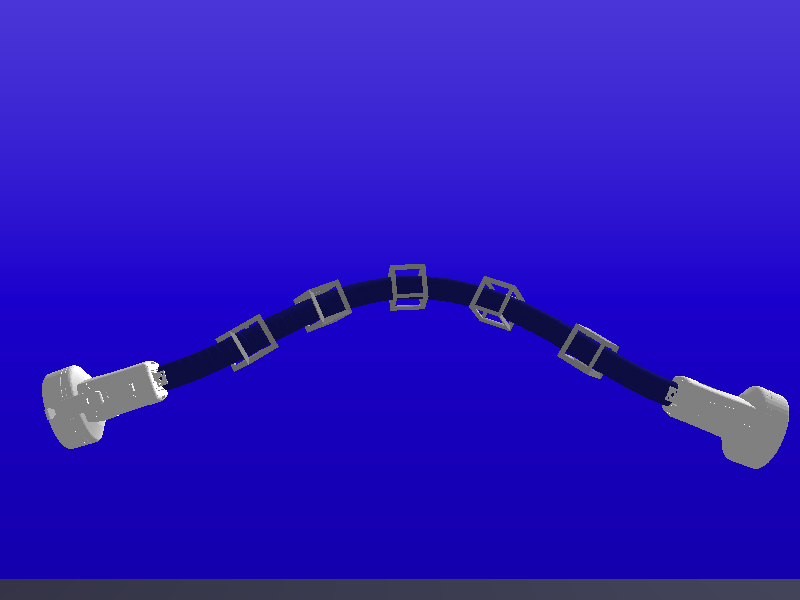

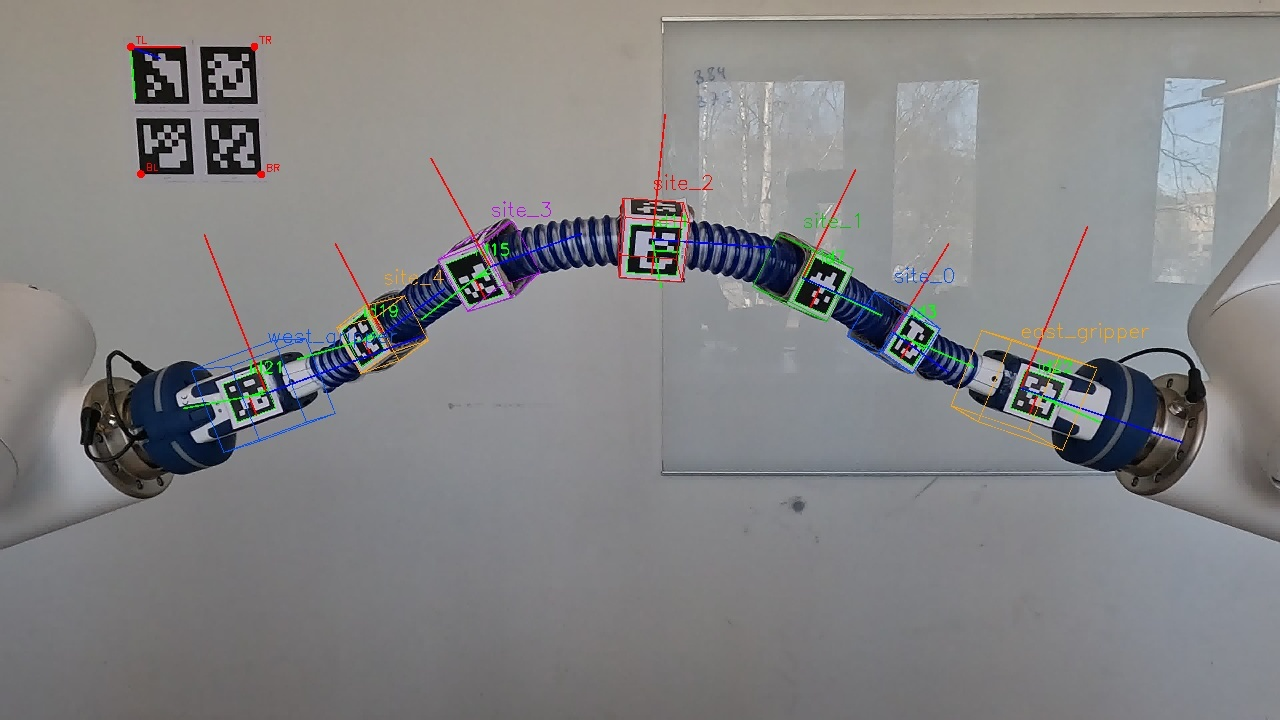

In [4]:
env.camera_rot = math.quat_from_axis_angle(jnp.array([0.0, 0.0, 1.0]), jnp.pi) #change jn.pi to zero
#Get first state
scene = EnvironmentScene(env, env_param, states[-1], show_text=False, show_fps=False, debug_render=False)
# kill old app attempt?
try:
    app.destroy()
except:
    pass
    
try:
    del scene
except:
    pass

#rebuild scene 
scene = EnvironmentScene(env, env_param, states[-1],
                         show_text=False,
                         show_fps=False,
                         debug_render=False)

#create new app
app = Application(scene, 60, "default", headless=True)

# render
scene.update_geometry()
img = app.get_headless_frame()
display(img)
img_real = Image.open("marker_data_new/frame_007229_pose.jpg")
img_real

In the cell above, we see a pose obtained from interpolation from the real marker data, followed by an image of the actual image of the last pose used in the data. Notice that the camera is located behind the DLO in the reconstructed image, but it is clear that the two match. 

In [5]:
#ANIMATE
import imageio
from IPython.display import Video

writer = imageio.get_writer("animation.mp4", fps=5)  # slower since only 9 frames

frames = []

for state in states:
    scene.state = state
    scene.update_geometry()

    app.graphicsEngine.renderFrame()
    frame = app.get_headless_frame()

    writer.append_data(np.array(frame))

writer.close()

Video("animation.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


In the cell below, we recreate the DLO environment and poses from the simulated data instead of the real one. This is due to inaccuracies in the real data results, and we therefore think it is better to present the rest of the procedure using the simulated data set. 

In [6]:

states=[]

#Open marker data file

with open("marker_data_new/simulated_dlo_marker_data.yaml", "r") as stream:
    data_loaded = yaml.safe_load(stream)



#
gripper_com_to_marker = jnp.array(data_loaded["gripper_com_to_marker"])
env = LockedDLO(
    sim_settings=SimulationSettings(timestep, True, Solver.DENSE_LINEAR),
    env_settings=DLOSettings.create(
        n_segments=6*9+5,
        length=data_loaded["length"],
        inner_radius=data_loaded["inner_radius"],
        outer_radius = data_loaded["outer_radius"],
        density=data_loaded["mass"] / (data_loaded["length"]*jnp.pi*(data_loaded["outer_radius"]**2 - data_loaded["inner_radius"]**2)),
        pose_estimate_linear_offsets=data_loaded["marker_displacements"],
        gripper1_offset=Transform(gripper_com_to_marker, math.Rotations.identity),
        gripper2_offset=Transform(-gripper_com_to_marker, math.Rotations.identity),
        loose_end=False,
    ),
)

nu = 0.333
E = 1e7
cable_param = CableParameters(
    youngs_modulus=E,
    shear_modulus=E / (2 * (1 + nu)),
    damping=env.default_param.sparse_param.cable_param.damping,
)

env_param = env.default_param.tree_replace(
    src={"sparse_param.cable_param": cable_param}
)

for sample_name, marker_pose in data_loaded["marker_poses"].items():

    # build marker transforms
    marker_transform_list = []
    for site_name, pose in marker_pose.items():
        marker_transform_list.append(
            Transform(
                jnp.array(pose["pos"]),
                jnp.array(pose["rot"])
            )
        )

    marker_transforms = Transform.stack(marker_transform_list)

    # convert to body + frame
    body_transforms = env.convert_marker_transforms_to_body_transforms(marker_transforms)

    frame_transforms = env.convert_body_transforms_to_frame_transforms(
        env_param, body_transforms
    )

    # build state
    state = env.get_state_by_interface_interpolation(
        env_param,
        [frame_transforms[0], frame_transforms[1], body_transforms]
    )

    # store it
    states.append(state)

state0 = states[0]


print("num segments:", state0.conf.pos.shape[0])
#print("first segment:", state0.conf.pos[0])
#print("last segment:", state0.conf.pos[-1])
print(len(states)) #to see that we get all states

num segments: 61
5


In order to estimate parameters $\hat \theta$, we must first formulate a cost function $J$ such that 
\begin{align}
\hat \theta = \text{argmin}_{\theta}J(\boldsymbol{x};\theta),
\end{align}
where $\boldsymbol{x}$ is a state. 

In this lab we choose $J=\Sigma_s ||r_s||^2$, where $r_s$ is the residual for state $s = 1,..,N$. But what is $r$? We tried to choose $r$ in accordance with both forward and inverse dynamics.

**Forward dynamics residual**

The forward dynamics given by the SPOOK-stepper is

$$
\begin{align}
\begin{bmatrix}
\boldsymbol{M} & -\boldsymbol{G}^T \\
\boldsymbol{G} & \boldsymbol{\Sigma}
\end{bmatrix}
\begin{bmatrix}
\boldsymbol{v}_{k+1} \\
\boldsymbol{\lambda}
\end{bmatrix}
=
\begin{bmatrix}
\boldsymbol{M}\boldsymbol{v}_k + \Delta t\, \boldsymbol{f} \\
4\gamma \Delta t\, \boldsymbol{g} + \gamma \boldsymbol{G}\boldsymbol{v}_k
\end{bmatrix}
\end{align}
$$

If configuration $\boldsymbol{q}_k$ is a static equilibrium, then $\boldsymbol{v}_k = \boldsymbol{v}_{k+1}=0$. This means that we define the residual for the forward dynamics $\boldsymbol{r}_{fwd} = \boldsymbol{v}_{k+1}$. \boldsymbol{v}_{k+1} corresponds to the velocity after one SPOOK-step, i.e. one simulation step. 

**Inverse dynamics residual**

For the inverse dynamics, we instead split the external force into $\boldsymbol{f} = \boldsymbol{f}_g + \boldsymbol{f}_{app}$. The applied force $\boldsymbol{f}_{app}$, given by 
\begin{align}
\boldsymbol{f}_{app}=
\boldsymbol{M}(\boldsymbol{v}_{k+1} - \boldsymbol{v}_k)
- \boldsymbol{f}_g
+ \frac{1}{\Delta t}\boldsymbol{\Sigma}^{-1}
\left(
\boldsymbol{G}^T \boldsymbol{G}\boldsymbol{v}_{k+1}
+ \frac{4\gamma}{\Delta t}\boldsymbol{G}^T \boldsymbol{g}
- \gamma \boldsymbol{G}^T \boldsymbol{G}\boldsymbol{v}_k
\right)
\end{align}


This is the force that is a driving force behind a trajectory. If the DLO is in static equilibrium and with the correct model parameters, then $\boldsymbol{f}_{app}=0$, thus $\boldsymbol{r}_{inv} = \boldsymbol{f}_{app}$. 


The set of parameters being optimized is Young's modulus $E$, which describes the relation between stress and normal strain (compressing and stretching) and shear modulus $G$, which describes the relation between shear stress and shear strain (deformation due to shear forces). 

In [7]:
from ajx.tree_util import tangent_jacfwd
from ajx.definitions import State, GeneralizedVelocity
from ajx.example_environments.dlo import DLOState

state_ini = states[0]
target_pose = state_ini.conf
lock_targets = state_ini.lock_targets
start_err = jnp.linalg.norm(state.gvel.data)
n_bodies = env.default_param.rigid_body_param.mass.shape[0]
multipliers = jnp.zeros_like(state.multipliers)

def forward_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
    state = DLOState(target_pose, gvel, lock_targets, multipliers)
    next_state = env.step_state(state, jnp.zeros([12]), param)
    return next_state.gvel.data.flatten()

def inverse_dynamics_residual(param):
    gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
    state = DLOState(target_pose, gvel, lock_targets, multipliers)
    force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)
    return force.flatten()

#functions with suffix multi-states concatenates the residuals of each state in order to get an optimization
#that considers every state. 
def forward_dynamics_residual_multi_states(param):
    residuals = []

    for s in states:
        target_pose = s.conf
        lock_targets = s.lock_targets

        gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
        state = DLOState(target_pose, gvel, lock_targets, multipliers)

        next_state = env.step_state(state, jnp.zeros([12]), param)

        residuals.append(next_state.gvel.data.flatten())

    return jnp.concatenate(residuals)

def inverse_dynamics_residual_multi_states(param):
    residuals = []

    for s in states:
        target_pose = s.conf
        lock_targets = s.lock_targets

        gvel = GeneralizedVelocity(jnp.zeros([n_bodies, 6]))
        state = DLOState(target_pose, gvel, lock_targets, multipliers)

        force = env.sim.inverse_dynamics(state, gvel, jnp.zeros([12]), param)

        residuals.append(force.flatten()) 

    return jnp.concatenate(residuals)


#Choice of residual and method to calc residual Jacobian
residual = forward_dynamics_residual_multi_states
jac_r = tangent_jacfwd(residual)

def gauss_newton(x0, max_iter, damping, tol):
    x = x0
    for i in range(max_iter):
        rx = residual(x)  
        J = jac_r(x) 
        if jnp.linalg.norm(rx)**2 < tol:
            return x, J

        # Gauss-Newton step: solve (J^T J) delta = -J^T r
        JTJ = J.T @ J + jnp.eye(J.shape[1]) * damping
        JTr = J.T @ rx
        delta = -jnp.linalg.solve(JTJ, JTr)
        #Print delta to debug
        #print(delta) 

        x = x.retract(delta)
        print(f"Iter: {i}\t |rx|: {jnp.linalg.norm(rx)} E: {x.sparse_param.cable_param.youngs_modulus} G: {x.sparse_param.cable_param.shear_modulus}")
        
        #singular value decomp for debug
        #u, s, vh = jnp.linalg.svd(J)
        #print(s) 
    return x, J


# Pretend that stiffness is unknown
env_param = env.default_param.tree_replace(src={
    "sparse_param.cable_param.youngs_modulus":  1e5,
    "sparse_param.cable_param.shear_modulus":  1e5,
})

# Set stiffness as tunable
env_param = env_param.replace(
    tangent_restrictions=(
        "sparse_param.cable_param.youngs_modulus",
        "sparse_param.cable_param.shear_modulus",
    )
)

# Optimize
solution, Js = gauss_newton(env_param, max_iter=50, damping=0.0, tol = 1e-3)

#Print condition number in order to get an idea of numerical suitability
#print(jnp.linalg.cond(Js))

#Print results
print(solution.sparse_param.cable_param.youngs_modulus)
print(solution.sparse_param.cable_param.shear_modulus)







Iter: 0	 |rx|: 31.34622194960354 E: 186918.02374393126 G: 117864.1451175305
Iter: 1	 |rx|: 17.12990026500006 E: 459824.97068634594 G: 253773.20374984638
Iter: 2	 |rx|: 13.609095264303761 E: 1070272.8781892469 G: 551397.2844007096
Iter: 3	 |rx|: 11.4355187790933 E: 2305809.0780026466 G: 1147257.1197769442
Iter: 4	 |rx|: 10.114644964466121 E: 4526480.6401875485 G: 2228929.3780368115
Iter: 5	 |rx|: 9.436122658521903 E: 6303426.70105221 G: 3114317.2754440946
Iter: 6	 |rx|: 9.317075507402498 E: 6740187.30269606 G: 3344995.5349058444
Iter: 7	 |rx|: 9.310590743355087 E: 6804751.02566302 G: 3380168.4285313715
Iter: 8	 |rx|: 9.31040360072977 E: 6814426.708222668 G: 3385344.5487696715
Iter: 9	 |rx|: 9.31040050831664 E: 6815536.883208173 G: 3385943.854015941
Iter: 10	 |rx|: 9.310400462532476 E: 6815678.482651012 G: 3386019.8301132303
Iter: 11	 |rx|: 9.31040046134695 E: 6815695.214527727 G: 3386028.842226502
Iter: 12	 |rx|: 9.310400461473979 E: 6815697.288234421 G: 3386029.956399672
Iter: 13	 |rx|

In [8]:
# Print results
youngs_modulus = solution.sparse_param.cable_param.youngs_modulus
shear_modulus = solution.sparse_param.cable_param.shear_modulus
poissons_ratio = youngs_modulus / (2 * shear_modulus) - 1
print(f"Poisson's ratio: {poissons_ratio}")
print(
    f"Youngs modulus, shear modulus: \t{youngs_modulus}, {shear_modulus}"
)

# Estimate uncertainty
U, S, V = jnp.linalg.svd(Js)

JTJ_inv = V @ jnp.diag((1/(S+1e-16))**2) @ V.T
residual_sample_variance = jnp.linalg.norm(residual(solution))**2 / (residual(solution).shape[0] - env_param.tangent_size())
cov = JTJ_inv * residual_sample_variance
parameter_std = jnp.sqrt(jnp.diag(cov))
print(f"Standard deviation estimate: \t\t{parameter_std[:3]}")

Poisson's ratio: 0.0064437338811580425
Youngs modulus, shear modulus: 	6815697.567676192, 3386030.106915543
Standard deviation estimate: 		[379247.85128347 192570.5042491 ]


In the cell above, the parameters $E$ and $G$ are optimized using the Gauss-Newton algorithm. The Gauss-Newton algorithm can be derived from minimizing the square of the Taylor expansion of $\boldsymbol{r(\hat \theta + \delta \hat \theta)}$ around the current parameter estimate and works by solving the system 
\begin{align}
\boldsymbol{J}^T\boldsymbol{J}\boldsymbol{\delta\hat \theta} = -\boldsymbol{J}^T\boldsymbol{r}
\end{align}
for $\boldsymbol{\delta\hat \theta}$, where $\boldsymbol{J}$ is the Jacobian of the residual wrt the parameters. 

The residual used was $\boldsymbol{r}_{fwd}$, since we were not able to get reliable results when using $\boldsymbol{r}_{inv}$ in the optimizer. The initial values used was $1e5$ for both $E$ and $G$. 

**Results**

The results when using the simulated data set was 

$E = 6.8e6$ 

$G = 3.4e6$

and when using the real data set:


$E = -1.9e4$

$G = -3e4$

which is obviously incorrect. 

The biggest challenge (which was never resolved unfortunately) was the fact that we could not get the optimizer to find good values for parameters when using the real data. The optimizer produces very large steps $\boldsymbol{\delta \hat \theta}$. That is the issue with the Gauss-Newton solver, it just takes a step without doing any sort of control evaluation. This could have possibly been resolved by using the TRF optimization approach, as in lab 3. In the TRF approach, we define a trust region in which it is safe to linearize the problem (like what is done in the Taylor expansion in derivation of Gauss-Newton), and if the step $\boldsymbol{\delta \hat \theta}$ falls into this region, it is accepted, and if not, it is rejected. 



**Sensitivity analysis**

In the cell below, a sensitivity analysis was performed by varying one parameter at a time in an interval close to the value obtained from the optimization and evaluating the cost ($J = ||r||^2$) for the values in the sweep. As seen in the figures, the optimization has worked since the cost is at a minimum at the values obtained from optimization. 

In [9]:
opt_youngs = youngs_modulus
opt_shear = shear_modulus

#opt_youngs = 8e6
#pt_shear = 4e6

delta_youngs = 1e4
delta_shear = 0.5*1e4

ini_youngs = opt_youngs/2
ini_shear = opt_shear/2

n_iter_youngs = int(1*opt_youngs/delta_youngs)
n_iter_shear = int(1*opt_shear/delta_shear)

residuals_youngs = []
residuals_shear = []

youngs_arr = []
shear_arr = []

base_param = env.default_param.tree_replace({
    "sparse_param.cable_param.shear_modulus": opt_shear,
})

#env_param = env.default_param.tree_replace(src={
#        "sparse_param.cable_param.shear_modulus":  opt_shear,
#    })



for i in range(n_iter_youngs):
    youngs_arr.append(ini_youngs+delta_youngs*i)
    env_param = base_param.tree_replace(src={
        "sparse_param.cable_param.youngs_modulus":  youngs_arr[i],
    })
    r = residual(env_param)
    residuals_youngs.append(jnp.sum(r**2))

base_param = env.default_param.tree_replace(src={
        "sparse_param.cable_param.youngs_modulus":  opt_youngs,
    })

for i in range(n_iter_shear):
    shear_arr.append(ini_shear+delta_shear*i)
    env_param = base_param.tree_replace(src={
        "sparse_param.cable_param.shear_modulus":  shear_arr[i],
    })
    r = residual(env_param)
    residuals_shear.append(jnp.sum(r**2))

residuals_shear = jnp.stack(residuals_shear)
shear_arr = jnp.stack(shear_arr)





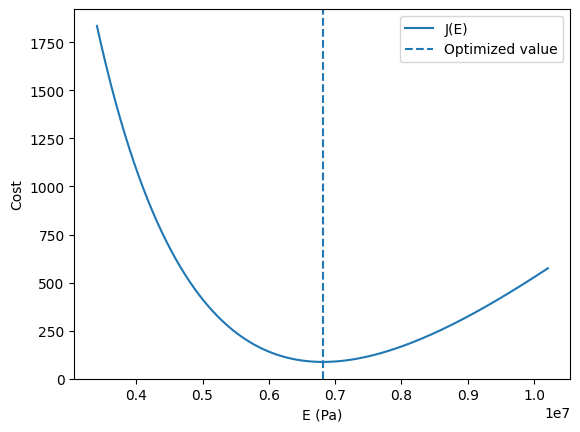

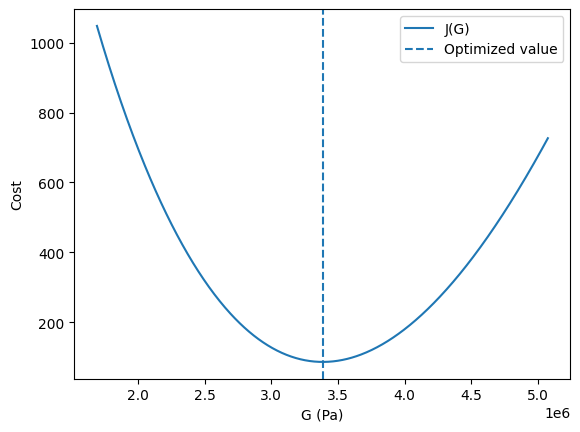

In [10]:
plt.figure(1)
plt.plot(youngs_arr, residuals_youngs, label="J(E)")
plt.axvline(opt_youngs, label="Optimized value", linestyle = "--")

plt.xlabel("E (Pa)")
plt.ylabel("Cost")
plt.legend()

plt.figure(2)
plt.plot(shear_arr, residuals_shear, label="J(G)")
plt.axvline(opt_shear, label="Optimized value", linestyle = "--")

plt.xlabel("G (Pa)")
plt.ylabel("Cost")
plt.legend()

**Reconstruction**

The last task of this lab was for us to reconstruct the poses in the real data set using the parameters obtained from the optimization with the help of the script dlo_sim.py. The poses from the real data, along with the reconstructed poses from AGX can be seen below. 

The simulated DLO captures the overall shape and deformation reasonably well. It does, however, seem as if the simulated DLO behaves a bit too flexible, which indicates that the estimated parameter values might be a bit low. Since these parameters were found from a simulated data set, the  reason for this could be that the algorithm is only able to find a local minimum of the residual when there could, in fact, be a more accurate solution. 

**Real Data Challenges**

Working with real data involves several challenges compared to simulated data. Real measurements are often affected by sensor noise and calibration errors, which can make the reconstructed DLO shapes less reliable. In this case, an issue could be the cameras not picking up depth accurately and thus not getting the correct positions in configurations. In real data, like the DLO, there can only be a finite number of tracking markers (7 in this case), which means that we have to interpolate in order to get full states. This, of course, introduces more errors. 



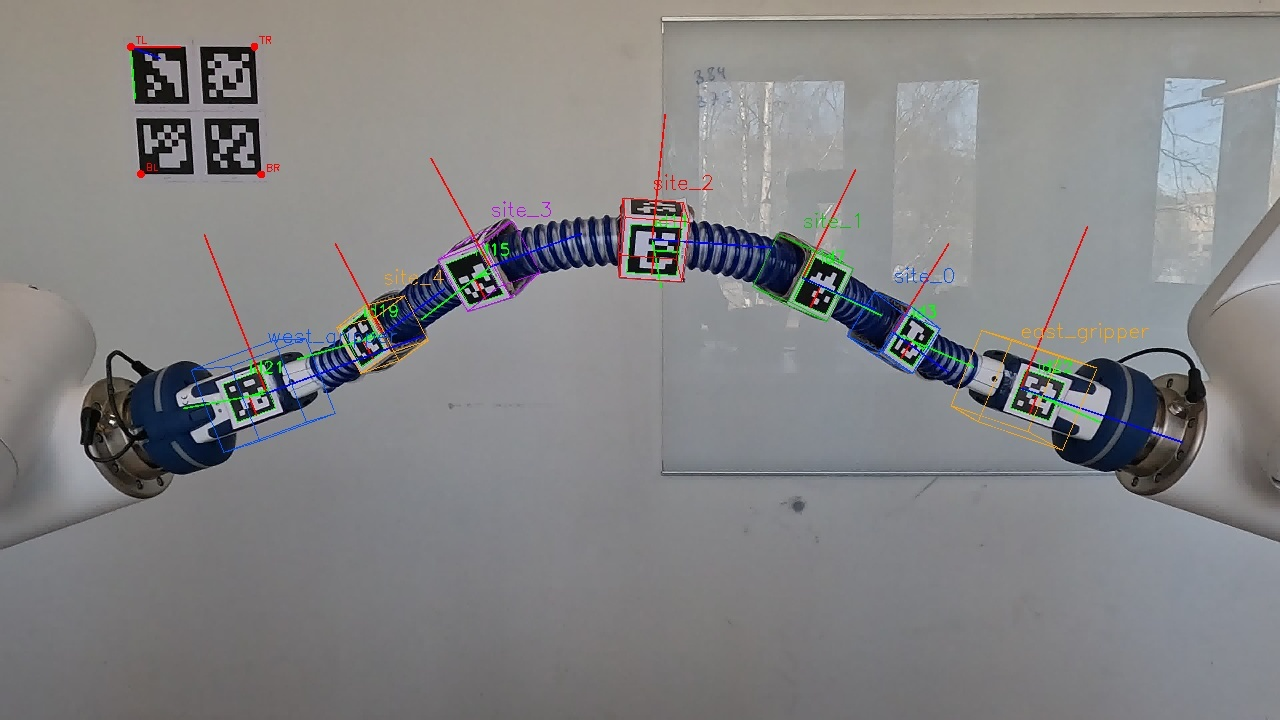

In [11]:
img_real_last = Image.open("marker_data_new/frame_007229_pose.jpg")
img_real_last



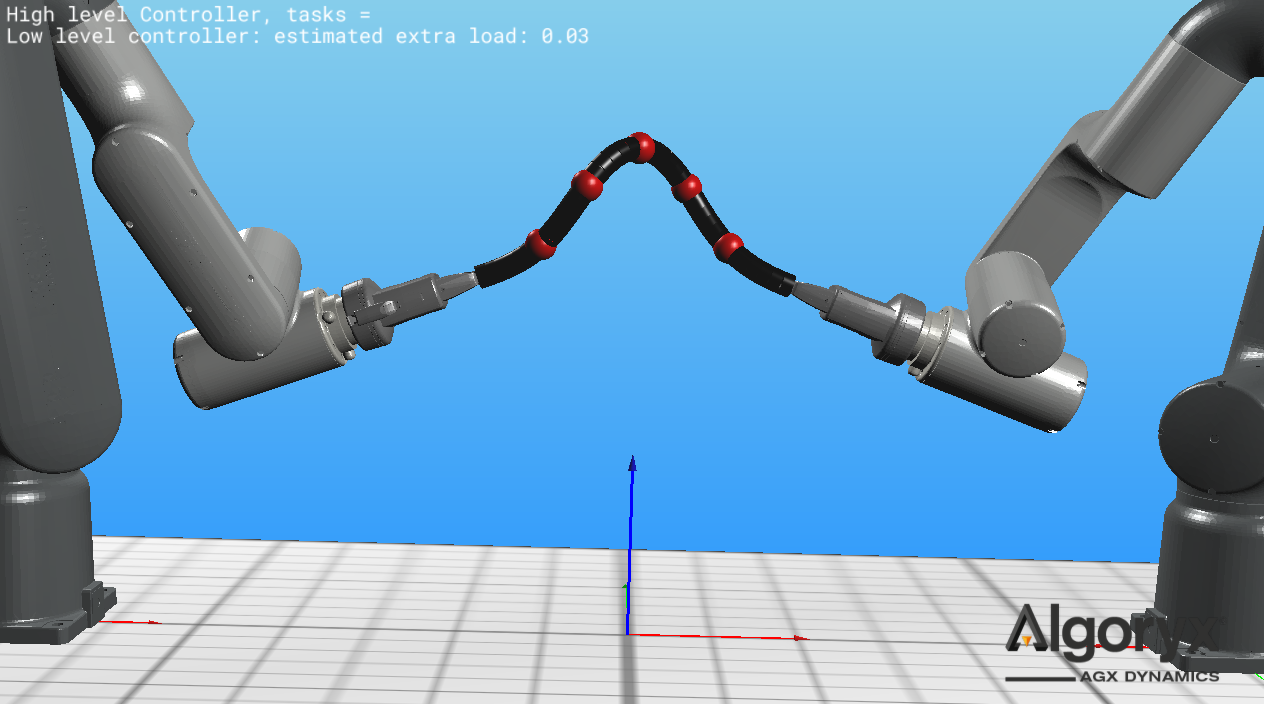

In [12]:
img_agx_last = Image.open("agx_figure/last_pose.png")
img_agx_last

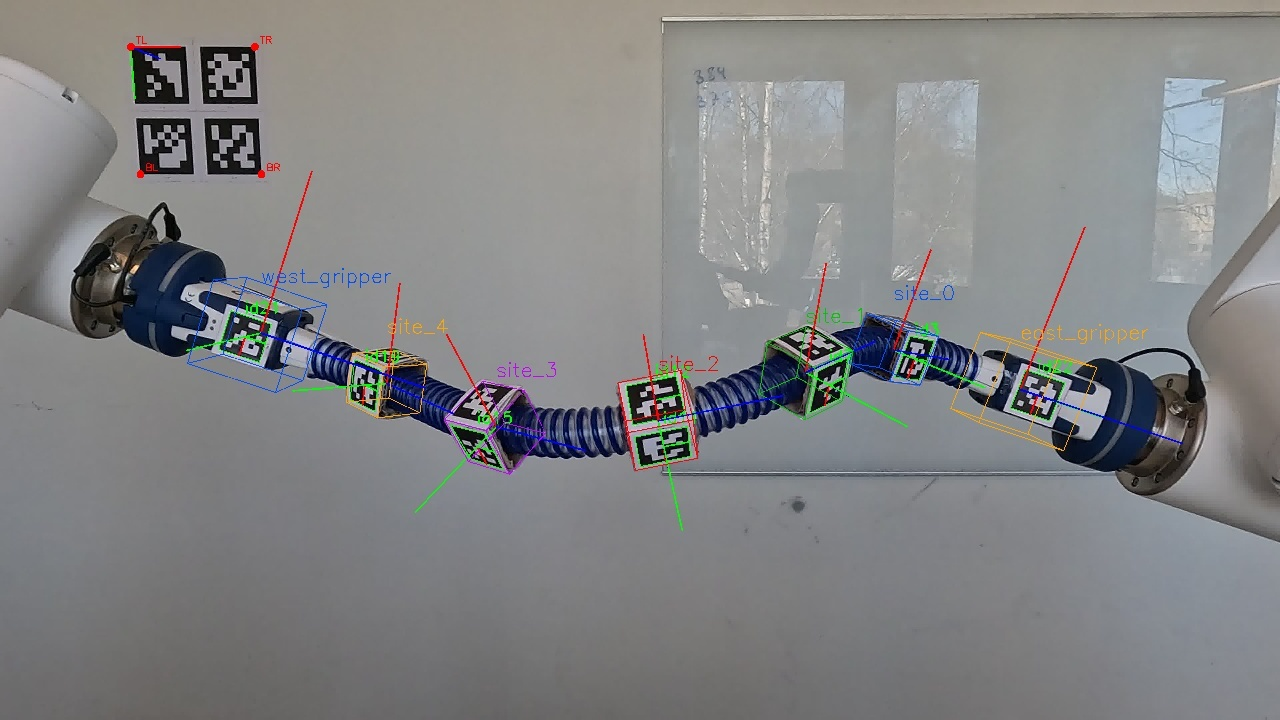

In [13]:
img_real_sec_last = Image.open("marker_data_new/frame_006510_pose.jpg")
img_real_sec_last

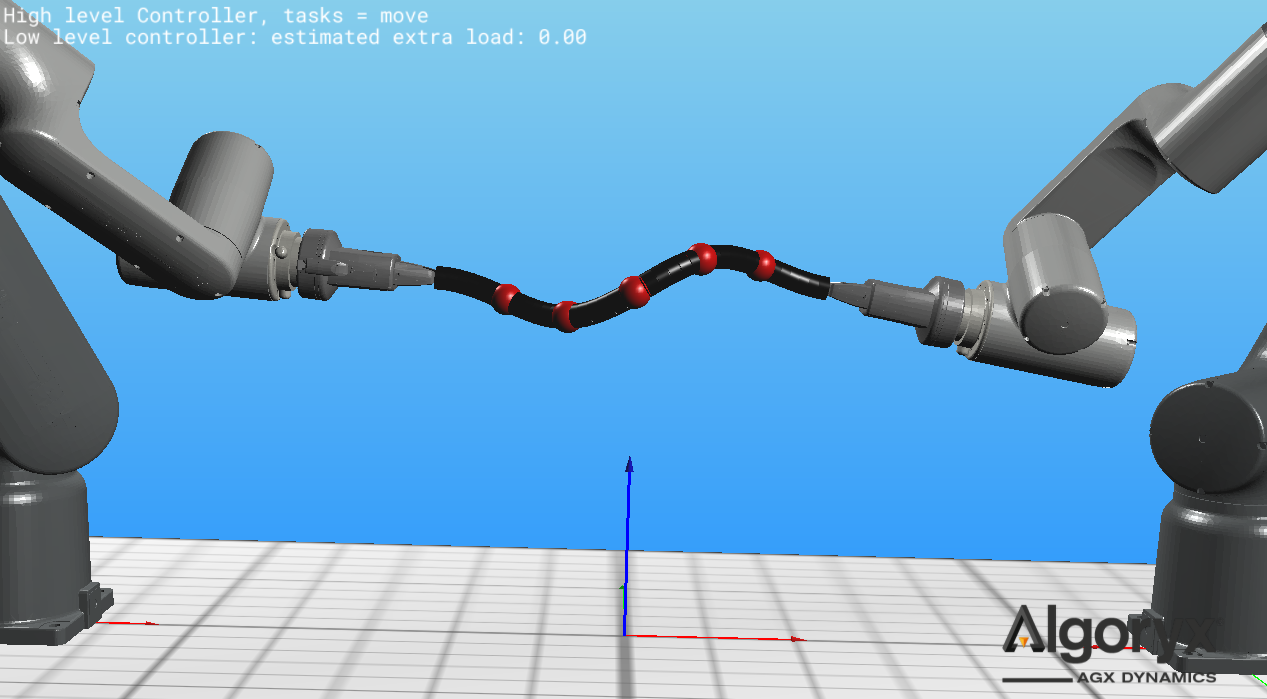

In [14]:
img_agx_sec_last = Image.open("agx_figure/nast_last_pose.png")
img_agx_sec_last